In [100]:
# with open('../Data/dataset.txt','r') as sentence:
#     dataset = sentence.read().splitlines() 
# this will read the file and split it into a list of sentences, where each sentence is an element in the list. 
# The splitlines() method is used to split the text at new line characters, effectively creating a list of sentences from the file.

In [101]:
import tensorflow as tf

In [102]:
file = tf.keras.utils.get_file(
    'shakespeare.txt',
    'https://storage.googleapis.com/download.tensorflow.org/data/shakespeare.txt'
)

In [103]:
text = open(file, 'rb').read().decode(encoding='utf-8')

In [104]:
text = text.lower()

In [105]:
lines = text.split('\n') # outputs a list of lines seperated by new line characters

In [106]:
dataset = []

In [107]:
for line in lines:
    line = line.strip() # removes leading and trailing whitespace characters from the line
    if len(line.split()) > 7: # checks if the line has 5 or more words 
        dataset.append(line) # adds the line to the dataset list if it has 5 or more characters

In [108]:
dataset = dataset[:2000]

In [109]:
len(dataset)

2000

In [110]:
dataset[:10]


['before we proceed any further, hear me speak.',
 'you are all resolved rather to die than to famish?',
 'first, you know caius marcius is chief enemy to the people.',
 "let us kill him, and we'll have corn at our own price.",
 "no more talking on't; let it be done: away, away!",
 'we are accounted poor citizens, the patricians good.',
 'what authority surfeits on would relieve us: if they',
 'would yield us but the superfluity, while it were',
 'wholesome, we might guess they relieved us humanely;',
 'but they think we are too dear: the leanness that']

In [111]:
lengths = []
for item in dataset:
    lengths.append(len(item.split(' ')))
max_length = max(lengths)
max_length

13

In [112]:
dataset[1]

'you are all resolved rather to die than to famish?'

In [113]:
lengths[:5]

[8, 10, 11, 12, 10]

## Integer Encoading

In [114]:
import tensorflow
from tensorflow.keras.preprocessing.text import Tokenizer

In [115]:
# tokenizer = Tokenizer(num_words=2000, oov_token='<nothing>')
tokenizer = Tokenizer(oov_token='<nothing>')

In [116]:
tokenizer.fit_on_texts(dataset)

In [117]:
# The word_counts attribute of the Tokenizer object is a dictionary where the keys are the unique words 
# in the dataset and the values are the number of times each word appears in the dataset.
tokenizer.word_counts

OrderedDict([('before', 25),
             ('we', 144),
             ('proceed', 5),
             ('any', 15),
             ('further', 10),
             ('hear', 28),
             ('me', 126),
             ('speak', 28),
             ('you', 438),
             ('are', 104),
             ('all', 90),
             ('resolved', 2),
             ('rather', 18),
             ('to', 501),
             ('die', 8),
             ('than', 79),
             ('famish', 2),
             ('first', 16),
             ('know', 37),
             ('caius', 6),
             ('marcius', 28),
             ('is', 157),
             ('chief', 2),
             ('enemy', 8),
             ('the', 753),
             ('people', 36),
             ('let', 43),
             ('us', 67),
             ('kill', 1),
             ('him', 181),
             ('and', 493),
             ("we'll", 8),
             ('have', 199),
             ('corn', 9),
             ('at', 52),
             ('our', 106),
             ('own', 2

In [118]:
# total number of sentences in the dataset
tokenizer.document_count

2000

In [119]:
# The word_index attribute of the Tokenizer object is a dictionary where the keys are the unique words 
# in the dataset and the values are the corresponding integer indices assigned to each word by the tokenizer.
tokenizer.word_index

{'<nothing>': 1,
 'the': 2,
 'to': 3,
 'and': 4,
 'you': 5,
 'i': 6,
 'of': 7,
 'a': 8,
 'he': 9,
 'that': 10,
 'in': 11,
 'not': 12,
 'have': 13,
 'your': 14,
 'my': 15,
 'him': 16,
 'as': 17,
 'for': 18,
 'his': 19,
 'with': 20,
 'it': 21,
 'is': 22,
 'but': 23,
 'be': 24,
 'we': 25,
 'me': 26,
 'this': 27,
 'our': 28,
 'are': 29,
 'if': 30,
 'will': 31,
 'all': 32,
 'so': 33,
 'what': 34,
 'do': 35,
 'by': 36,
 'they': 37,
 'than': 38,
 'would': 39,
 'them': 40,
 'shall': 41,
 'their': 42,
 'no': 43,
 'when': 44,
 'which': 45,
 'thou': 46,
 'us': 47,
 'was': 48,
 'rome': 49,
 'one': 50,
 'were': 51,
 'had': 52,
 'thy': 53,
 'more': 54,
 'at': 55,
 'good': 56,
 'say': 57,
 'from': 58,
 'thee': 59,
 'come': 60,
 'on': 61,
 'or': 62,
 'yet': 63,
 "o'": 64,
 'make': 65,
 'must': 66,
 'let': 67,
 'go': 68,
 'an': 69,
 'did': 70,
 'like': 71,
 'now': 72,
 'should': 73,
 "i'll": 74,
 'out': 75,
 'upon': 76,
 'am': 77,
 'know': 78,
 'hath': 79,
 'then': 80,
 'how': 81,
 'people': 82,
 'well

In [120]:
len(tokenizer.word_index)
# total number of unique words in the dataset

3037

In [121]:
dataset[0]

'before we proceed any further, hear me speak.'

In [ ]:
tokenizer.texts_to_sequences('the teacher is on the box')

# When we pass a plain string, TensorFlow treats it as an iterable of characters:
# ['t', 'h', 'e', ' ', 't', 'e', ...]
# To get the expected behavior, we need to pass a list of strings, even if it's just one string:

In [123]:
tokenizer.texts_to_sequences(['the stupid teacher keeps smoking cigeratte'])
# allways remember that the output is a list of lists, where each inner list corresponds to the tokenized version of the input string.

[[2, 1, 1, 1, 1509, 1]]

In [124]:
tokenizer.texts_to_sequences(dataset[:5])

[[116, 25, 401, 176, 227, 99, 26, 100],
 [5, 29, 32, 802, 144, 3, 270, 38, 3, 803],
 [163, 5, 78, 342, 101, 22, 804, 271, 3, 2, 82],
 [67, 47, 1248, 16, 4, 272, 13, 248, 55, 28, 131, 585],
 [43, 54, 1249, 477, 67, 21, 24, 126, 177, 177]]

### forming the chain of words to predict the next

In [125]:
len([[1,5,7,2]])

1

In [126]:
sequence = []
# allways remember that the output is a list of lists, where each inner list corresponds to the tokenized version of the input string.

for sentence in dataset:

    tokenized_sentence = tokenizer.texts_to_sequences([sentence])[0]
    for i in range(1, len(tokenized_sentence)):
        sequence.append(tokenized_sentence[:i+1])

In [127]:
sequence[:16]

[[116, 25],
 [116, 25, 401],
 [116, 25, 401, 176],
 [116, 25, 401, 176, 227],
 [116, 25, 401, 176, 227, 99],
 [116, 25, 401, 176, 227, 99, 26],
 [116, 25, 401, 176, 227, 99, 26, 100],
 [5, 29],
 [5, 29, 32],
 [5, 29, 32, 802],
 [5, 29, 32, 802, 144],
 [5, 29, 32, 802, 144, 3],
 [5, 29, 32, 802, 144, 3, 270],
 [5, 29, 32, 802, 144, 3, 270, 38],
 [5, 29, 32, 802, 144, 3, 270, 38, 3],
 [5, 29, 32, 802, 144, 3, 270, 38, 3, 803]]

In [128]:
# printing specific words corresponding to their indices in the tokenizer's word index
tokenizer.index_word[1020]  # This will print the word corresponding to index 1020 in the tokenizer's word index.

'commit'

In [129]:
len(sequence)

16141

## Padding

In [130]:
from tensorflow.keras.preprocessing.sequence import pad_sequences

In [131]:
max_length

13

In [132]:
pad_sequences = pad_sequences(sequence, maxlen=max_length, padding='pre')

In [133]:
pad_sequences[:5]

array([[  0,   0,   0,   0,   0,   0,   0,   0,   0,   0,   0, 116,  25],
       [  0,   0,   0,   0,   0,   0,   0,   0,   0,   0, 116,  25, 401],
       [  0,   0,   0,   0,   0,   0,   0,   0,   0, 116,  25, 401, 176],
       [  0,   0,   0,   0,   0,   0,   0,   0, 116,  25, 401, 176, 227],
       [  0,   0,   0,   0,   0,   0,   0, 116,  25, 401, 176, 227,  99]],
      dtype=int32)

## Break into X and Y

In [134]:
import numpy as np

In [135]:
X = pad_sequences[:, 0:-1]

In [136]:
X[:5]

array([[  0,   0,   0,   0,   0,   0,   0,   0,   0,   0,   0, 116],
       [  0,   0,   0,   0,   0,   0,   0,   0,   0,   0, 116,  25],
       [  0,   0,   0,   0,   0,   0,   0,   0,   0, 116,  25, 401],
       [  0,   0,   0,   0,   0,   0,   0,   0, 116,  25, 401, 176],
       [  0,   0,   0,   0,   0,   0,   0, 116,  25, 401, 176, 227]],
      dtype=int32)

In [137]:
Y = pad_sequences[:, -1]

In [138]:
pad_sequences[-1]

array([   0,    0,    0,    0,   68,  799,    2, 3037,   10,   46,  312,
        306,  377], dtype=int32)

In [139]:
pad_sequences[2512]

array([  0,   0,   0,   0,   0,   0,   0,   0,   0,   0, 376, 933,  11],
      dtype=int32)

In [140]:
Y[:5]

array([ 25, 401, 176, 227,  99], dtype=int32)

In [141]:
Y[:5]

array([ 25, 401, 176, 227,  99], dtype=int32)

In [142]:
idx = np.random.permutation(len(X))
X = X[idx]
Y = Y[idx]

# len(X) = 5
# [3, 0, 4, 1, 2]
# X = [X[3], X[0], X[4], X[1], X[2]]
# Y = [Y[3], Y[0], Y[4], Y[1], Y[2]]

In [143]:
X.shape

(16141, 12)

In [144]:
Y.shape

(16141,)

In [145]:
# from tensorflow.keras.utils import to_categorical

In [146]:
vocab_size = len(tokenizer.word_index)
vocab_size
# here we have 78 unique words
# so after one-hot encoding, we will have 78 columns in the output for each word in the vocabulary. 

3037

In [147]:
from tensorflow.keras.utils import to_categorical

In [149]:
Y = to_categorical(Y, num_classes=vocab_size+1)

# here we have done categorical encoding of the target variable Y, which is necessary for training a neural network model 
# for multi-class classification because the output layer of the model will have as many neurons as there are unique words in the dataset, 
# and each neuron will represent a class corresponding to a specific word.

# this is also known as one-hot encoding, where each class (word) is represented as a binary vector with a single high (1) 
# value and the rest low (0) values.

# for example,
# if we have 5 unique words in the dataset, and the target variable Y has a value of 3 
# (which corresponds to the 3rd word in the tokenizer's word index),
# the one-hot encoded vector for that target variable would be [0, 0, 1, 0, 0], 
# where the 1 is in the position corresponding to the 3rd word in the tokenizer's word index.

# our model output will be a probability distribution over all the unique words in the dataset, and the one-hot encoded target variable 
# will allow us to calculate the loss and update the model weights during training.


# here using LSTM we are solving a classification problem, where the model will learn to predict the next word in a sequence based 
# on the previous words. Since the output is a categorical variable (the next word), we need to convert it into a format that can
#  be used for training the model, which is what to_categorical does by converting the integer labels into a binary matrix representation.

In [150]:
Y[0]

array([0., 0., 0., ..., 0., 0., 0.], shape=(3038,))

## LSTM

In [153]:
from tensorflow.keras.models import Sequential
from tensorflow.keras.layers import Input, Embedding, LSTM, Dense

In [154]:
print(Y.shape)
print(Y[0])

(16141, 3038)
[0. 0. 0. ... 0. 0. 0.]


In [160]:
model = Sequential([
    Input(shape=(12,)),  # Each input sample is a sequence of 12 token IDs
    Embedding(input_dim=vocab_size+1, output_dim=100, mask_zero=True),
    # Converts each token ID into a 64-dimensional dense vector
    # Output shape: (batch_size, 11, 64)

    LSTM(100, return_sequences=True, dropout=0.2),
    # Processes the embedded sequence and returns the hidden state at every time step
    # Output shape: (batch_size, 6, 25)

    LSTM(50, dropout=0.2),
    # Processes the sequence of hidden states from the previous LSTM
    # Since return_sequences=False by default, only the final hidden state is returned
    # Output shape: (batch_size, 10)

    Dense(vocab_size+1, activation='softmax')
    # Produces a probability distribution over the 79-word vocabulary
    # Output shape: (batch_size, 79)
])

In [161]:
model.summary()

Model: "sequential_2"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ embedding_2 (Embedding)         │ (None, 12, 100)        │       303,800 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ lstm_4 (LSTM)                   │ (None, 12, 100)        │        80,400 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ lstm_5 (LSTM)                   │ (None, 50)             │        30,200 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_2 (Dense)                 │ (None, 3038)           │       154,938 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 569,338 (2.17 MB)

 Trainable params: 569,338 (2.17 MB)

 Non-trainable params: 0 (0.00 B)

In [162]:
model.compile(loss='categorical_crossentropy', optimizer='adam', metrics=['accuracy'])

In [163]:
from tensorflow.keras.callbacks import EarlyStopping

In [164]:
early_stop = EarlyStopping(
    monitor='val_loss',
    patience=5,
    restore_best_weights=True
)

In [ ]:
history = model.fit(
    X,
    Y,
    epochs=150,
    batch_size=64,
    validation_split=0.2,
    verbose=1
)

In [166]:
model.save("next_word_model.keras")

In [167]:
import pickle

with open("tokenizer.pkl", "wb") as f:
    pickle.dump(tokenizer, f)

In [168]:
with open("max_length.txt", "w") as f:
    f.write(str(max_length))

In [169]:
import matplotlib.pyplot as plt

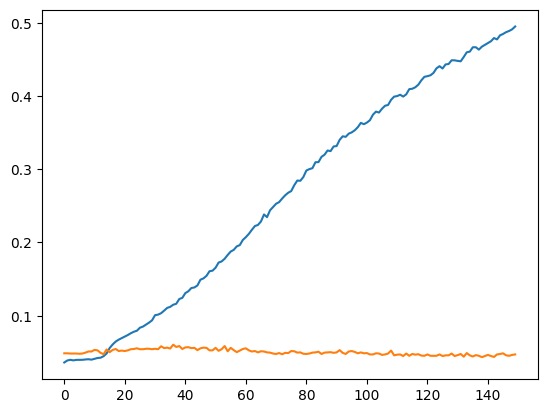

In [171]:
plt.plot(history.history['accuracy'])
plt.plot(history.history['val_accuracy'])

## prediction

In [172]:
with open("max_length.txt", "r") as f:
    max_length = int(f.read())

In [173]:
with open("tokenizer.pkl", "rb") as f:
    tokenizer = pickle.load(f)

In [174]:
from tensorflow.keras.models import load_model

model = load_model("next_word_model.keras")

In [183]:
import numpy as np
from tensorflow.keras.preprocessing.sequence import pad_sequences

text = "hate"

for i in range(10):

    # tokenize
    token_text = tokenizer.texts_to_sequences([text])[0]

    # pad
    padded_token_text = pad_sequences(
        [token_text],
        maxlen=max_length - 1,
        padding='pre'
    )

    # predict probabilities
    prediction = model.predict(
        padded_token_text,
        verbose=0
    )

    # highest probability word index
    pos = np.argmax(prediction)

    # convert index -> word
    for word, index in tokenizer.word_index.items():

        if index == pos:

            text = text + " " + word

            print(text)

            break

hate you
hate you punish
hate you punish instantly
hate you punish instantly and
hate you punish instantly and might
hate you punish instantly and might am
hate you punish instantly and might am content
hate you punish instantly and might am content for
hate you punish instantly and might am content for not
hate you punish instantly and might am content for not our


In [1268]:
tokenizer.word_index

{'<nothing>': 1,
 'the': 2,
 'and': 3,
 'to': 4,
 'i': 5,
 'of': 6,
 'you': 7,
 'my': 8,
 'that': 9,
 'in': 10,
 'a': 11,
 'he': 12,
 'not': 13,
 'for': 14,
 'is': 15,
 'with': 16,
 'me': 17,
 'your': 18,
 'it': 19,
 'his': 20,
 'have': 21,
 'but': 22,
 'be': 23,
 'him': 24,
 'as': 25,
 'this': 26,
 'thou': 27,
 'so': 28,
 'we': 29,
 'thy': 30,
 'will': 31,
 'all': 32,
 'our': 33,
 'what': 34,
 'by': 35,
 'are': 36,
 'if': 37,
 'do': 38,
 'no': 39,
 'on': 40,
 'shall': 41,
 'thee': 42,
 'they': 43,
 'from': 44,
 'lord': 45,
 'which': 46,
 'good': 47,
 'their': 48,
 'when': 49,
 'would': 50,
 'was': 51,
 'than': 52,
 'them': 53,
 'at': 54,
 'now': 55,
 'us': 56,
 'had': 57,
 'were': 58,
 'come': 59,
 'then': 60,
 'more': 61,
 'her': 62,
 'say': 63,
 'one': 64,
 'or': 65,
 'let': 66,
 'hath': 67,
 'god': 68,
 'make': 69,
 'yet': 70,
 'king': 71,
 'well': 72,
 'how': 73,
 'go': 74,
 'am': 75,
 'did': 76,
 'must': 77,
 'here': 78,
 'should': 79,
 'o': 80,
 'may': 81,
 'love': 82,
 'death':